<a href="https://colab.research.google.com/github/gshaurya27/SOC-26---Face-Ageing-Model/blob/main/WEEK%204/PyTorch_AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn , optim
from torchvision import datasets , transforms
import torch.nn.functional as F

import zipfile

import shutil
import os
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
from torch.nn.modules.conv import Conv2d
import torch
from torch import nn

class AlexNet(nn.Module):

  def __init__(self, num_classes=2):
    super(AlexNet, self).__init__()

    self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=64, out_channels=192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
    )

    self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

    self.Linear = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features=256*6*6, out_features=4096),
            nn.ReLU(inplace=True),

            nn.Dropout(0.5),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(inplace=True),

            nn.Linear(in_features=4096, out_features=num_classes)
    )

  def forward(self, x):
    x = self.conv1(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.Linear(x)
    return torch.sigmoid(x)

In [12]:
model = AlexNet()

In [13]:
!mkdir data_faces

In [16]:
!wget https://s3-us-west-1.amazonaws.com/udacity-dlnfd/datasets/celeba.zip

--2026-06-25 15:41:45--  https://s3-us-west-1.amazonaws.com/udacity-dlnfd/datasets/celeba.zip
Resolving s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)... 16.15.0.138, 16.15.4.235, 16.15.0.238, ...
Connecting to s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)|16.15.0.138|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1443490838 (1.3G) [application/zip]
Saving to: ‘celeba.zip’

celeba.zip          100%[===================>]   1.34G  28.3MB/s    in 44s     

2026-06-25 15:42:29 (31.3 MB/s) - ‘celeba.zip’ saved [1443490838/1443490838]



In [17]:
with zipfile.ZipFile('celeba.zip', 'r') as zip_ref:
    zip_ref.extractall('data_faces/')

In [18]:
root = '/content/data_faces/img_align_celeba'
img_list = os.listdir(root)
print(len(img_list))


202599


In [21]:
df = pd.read_csv('list_attr_celeba.csv')
df = df[['image_id','Smiling']]
df

,image_id,Smiling
0,000001.jpg,1
1,000002.jpg,1
2,000003.jpg,-1
3,000004.jpg,-1
4,000005.jpg,-1
...,...,...
202594,202595.jpg,-1
202595,202596.jpg,1
202596,202597.jpg,1
202597,202598.jpg,1


In [22]:
num = 1500

s0,s1 = 0,0

In [35]:
import os
import shutil

# Create the base 'Data' directory if it doesn't exist
if not os.path.exists('Data'):
    os.makedirs('Data')

# Create 'Data/Smile' and 'Data/Nosmile' directories if they don't exist
if not os.path.exists('Data/Smile'):
    os.makedirs('Data/Smile')
if not os.path.exists('Data/Nosmile'):
    os.makedirs('Data/Nosmile')

# Remove .ipynb_checkpoints if it exists inside 'Data/'
ipynb_checkpoints_path = os.path.join('Data', '.ipynb_checkpoints')
if os.path.exists(ipynb_checkpoints_path) and os.path.isdir(ipynb_checkpoints_path):
    shutil.rmtree(ipynb_checkpoints_path)

for i, (_,i_row) in enumerate(df.iterrows()):
  if s0<num:
    if i_row['Smiling'] == 1:
      s0 += 1
      shutil.copyfile('data_faces/img_align_celeba/'  + i_row['image_id'], 'Data/Smile/' + i_row['image_id'])
  if s1<num:
    if i_row['Smiling'] == -1:
      s1 += 1
      shutil.copyfile('data_faces/img_align_celeba/'  + i_row['image_id'], 'Data/Nosmile/' + i_row['image_id'])

In [36]:
img_list = os.listdir('Data/Smile')
img_list.extend(os.listdir('Data/Nosmile'))
print(len(img_list))

2993


In [38]:
import os
import shutil

transform = transforms.Compose([
                                transforms.Resize((64,64)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

])

# Ensure .ipynb_checkpoints is removed just before ImageFolder is called
ipynb_checkpoints_path = os.path.join('/content/Data', '.ipynb_checkpoints')
if os.path.exists(ipynb_checkpoints_path) and os.path.isdir(ipynb_checkpoints_path):
    shutil.rmtree(ipynb_checkpoints_path)

celeba_data = datasets.ImageFolder('/content/Data', transform=transform)

In [39]:
print(celeba_data.classes)
print(len(celeba_data))


['Nosmile', 'Smile']
2993


In [40]:
train_size = int(len(celeba_data)*0.75)
test_size = len(celeba_data) - train_size
train_set , test_set = torch.utils.data.random_split(celeba_data , [train_size , test_size])

In [42]:
trainLoader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
testLoader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=True)

In [43]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


In [44]:
epochs = 10
train_loss = []

for epoch in range(epochs):
  total_train_loss = 0

  for idx, (image,label) in enumerate(trainLoader):
    image = image.to(device)
    label = label.to(device)

    optimizer.zero_grad()
    output = model(image)
    loss = criterion(output, label)

    loss.backward()
    optimizer.step()

    total_train_loss += loss.item()

  total_train_loss = total_train_loss / (idx+1)
  train_loss.append(total_train_loss)

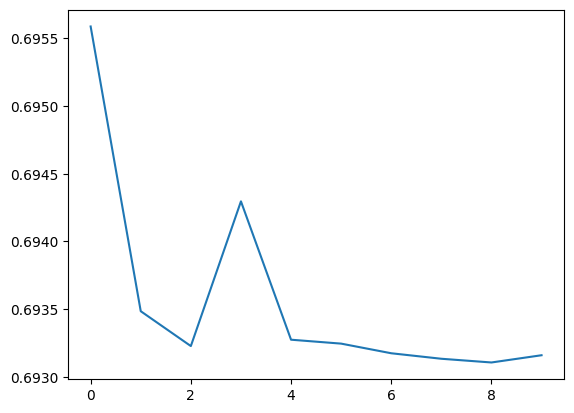

In [46]:
plt.plot(train_loss)

In [47]:
testiter = iter(testLoader)
images , labels = next(testiter)


In [48]:
with torch.no_grad():
  pred = model(images)


In [49]:
image_np = [i.cpu() for i in images]
class_names = celeba_data.classes


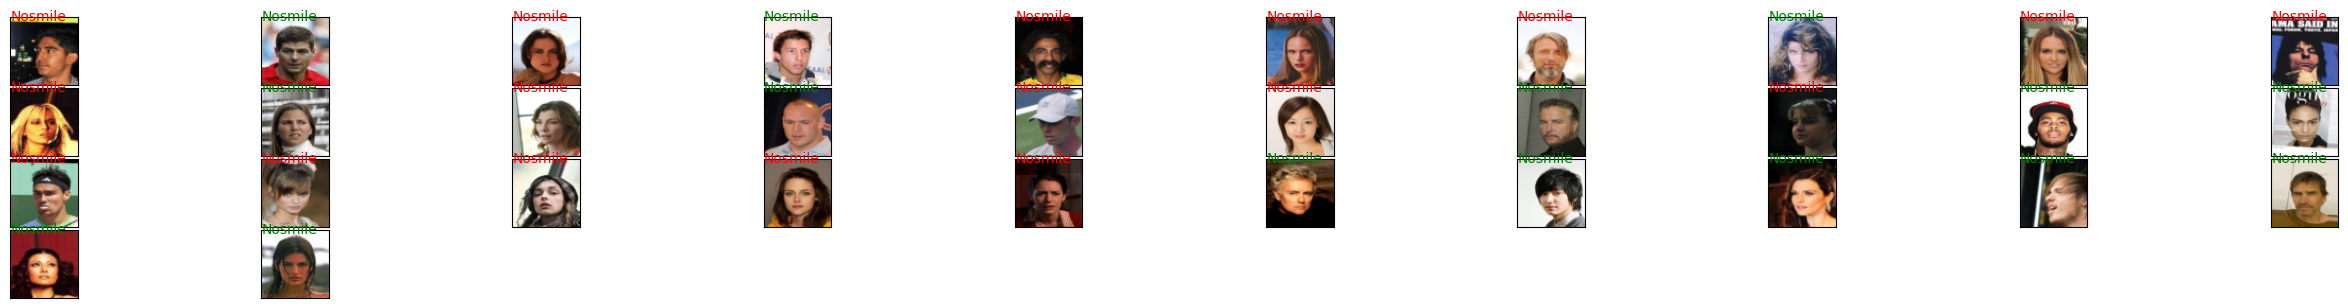

In [52]:
fig = plt.figure(figsize=(25, 4))
fig.subplots_adjust(left =0 , right = 1 , bottom = 0 , hspace=0.05 , wspace = 0.05)

for i in range(len(image_np)): # Iterate over the actual number of images in the batch
  ax = fig.add_subplot(5, 10, i + 1, xticks=[], yticks=[])
  # Denormalize image data from [-1, 1] to [0, 1] for correct display
  img_to_show = image_np[i].permute(1,2,0).numpy() # Convert to HWC format
  img_to_show = (img_to_show * 0.5) + 0.5 # Denormalize
  img_to_show = np.clip(img_to_show, 0, 1) # Clip to ensure values are within [0, 1]
  ax.imshow(img_to_show)

  if labels[i] == torch.max(pred[i], 0)[1]:
    ax.text(0,3,class_names[torch.max(pred[i], 0)[1]], color='green', fontsize=10)
  else:
    ax.text(0,3,class_names[torch.max(pred[i], 0)[1]], color='red', fontsize=10)